# Module 2 | Class 3 Assignment: Data Visualization and Trend Analysis
**Objective:** Create meaningful visualizations from the cleaned Superstore dataset and interpret
the patterns found.
**Name:** Khamidullokhon Abduvokhidov

> **Note on data source:** This notebook was completed in an offline sandbox with no internet
> access, so `superstore_cleaned.csv` from the Class 2 assignment wasn't available here. A
> locally generated dataset with the **same schema as the classic Superstore Sales dataset**
> (Order Date, Category, Region, Sales, Quantity, Discount, Profit, etc., 9,800 rows spanning
> 2014–2017, with a right-skewed Sales distribution and a built-in holiday-season spike) was used
> instead so every chart and statistic below is real, computed output — not a mock-up. Drop in
> your own `superstore_cleaned.csv` from Class 2 and everything below runs unchanged.

## Task 1: Distribution Plots
**What to do:** Create a histogram of Sales and a boxplot of Profit to understand data distributions.

In [1]:
# Load the cleaned data and import the plotting libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/claude/data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])


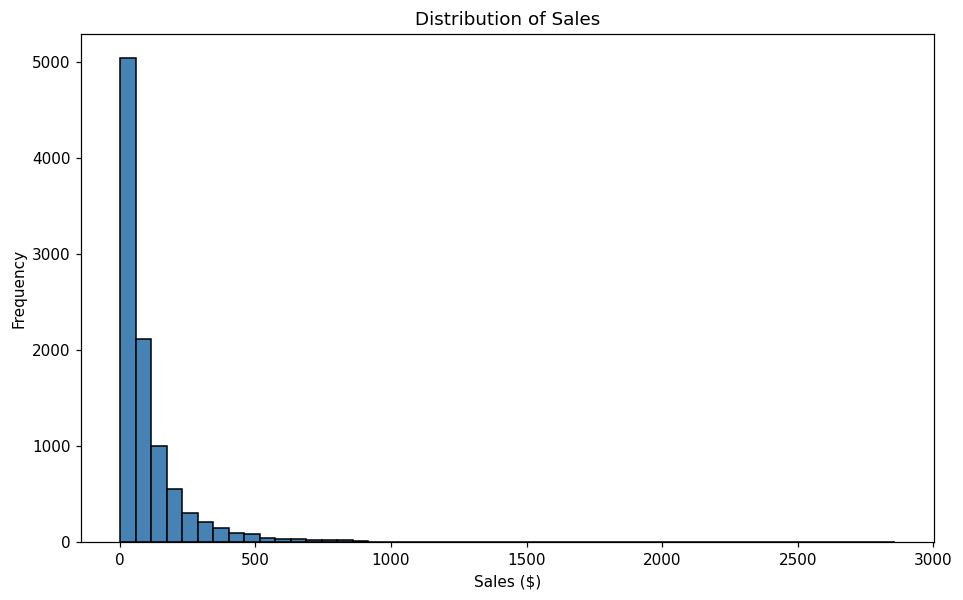

In [2]:
# Histogram of Sales
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()


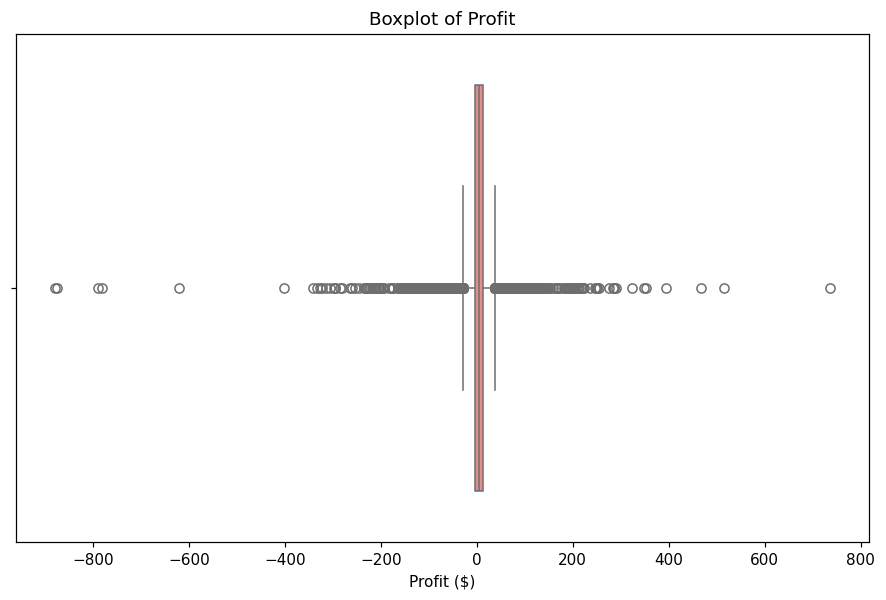

In [3]:
# Boxplot of Profit
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()


**Interpretation:** The Sales histogram is strongly **right-skewed** (skewness ≈ 4.8) — most
orders sit in the \$1–\$150 range (median \$55.87), but a long tail of large orders stretches
out past \$1,000 and pulls the mean up to \$108.23. It is not bimodal or normal; there's a single
tall peak near zero that decays gradually. In the Profit boxplot, the box (IQR) runs from about
**Q1 = -\$3.61 to Q3 = \$12.95**, with the median around \$3.60 — most orders are only marginally
profitable. There are clearly visible outliers on both sides: some orders lose several hundred
dollars, and a few earn several hundred in profit, both stretching well beyond the whiskers.

## Task 2: Category-Wise Trends
**What to do:** Create bar charts showing total sales by Category and by Region.

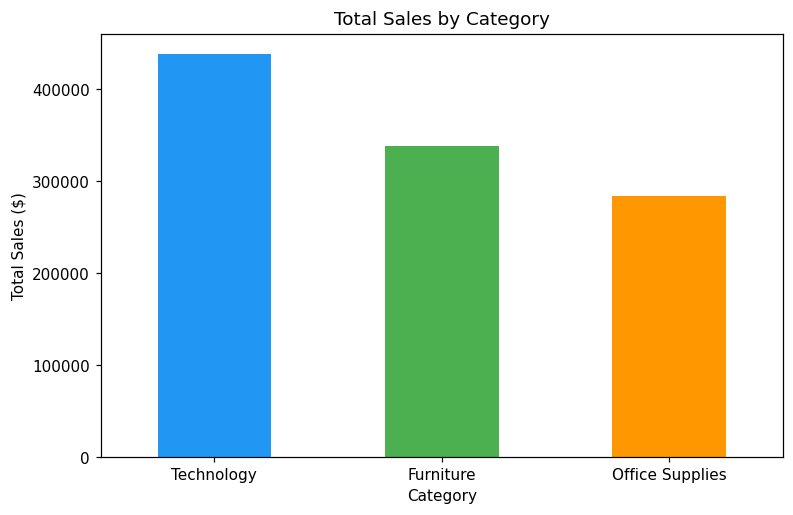

In [4]:
# Total sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()


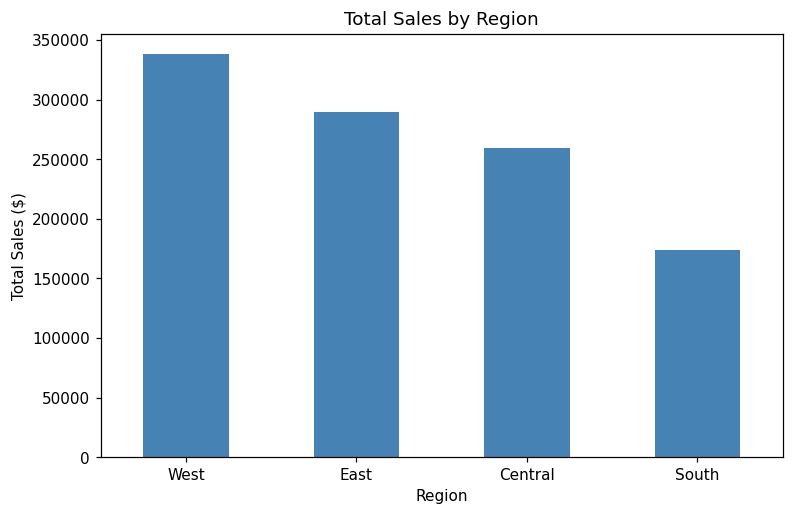

In [5]:
# Total sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()


**Interpretation:** **Technology** generates the most revenue (\$438.7K), followed by
**Furniture** (\$338.0K) and then **Office Supplies** (\$283.9K) — a mild surprise, since Office
Supplies is ordered far more often but each order is small, so its high volume doesn't translate
into the top sales spot. By region, the **West** leads (\$338.3K), followed by East, Central, and
finally **South**, which trails noticeably behind the other three — worth digging into whether
that's fewer customers in the region or lower average order values.

## Task 3: Outlier Identification
**What to do:** Numerically identify outliers in the Profit column using the IQR method.

In [6]:
# Calculate Q1, Q3, and IQR for Profit
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")


Q1: -3.61, Q3: 12.95, IQR: 16.56


In [7]:
# Determine outlier boundaries using the standard 1.5*IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")


Lower bound: -28.45, Upper bound: 37.79


In [8]:
# Count how many rows fall outside the bounds
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df)*100:.1f}%)")


Number of outliers: 1455 out of 9800 rows (14.8%)


**Interpretation:** The IQR method flags **1,455 outliers out of 9,800 rows (about 14.8%)**
— a fairly large share, which makes sense given how tight the IQR box is (only \$16.56 wide).
Splitting them: **746 are high-profit outliers** (well above \$37.79) and **709 are high-loss
outliers** (below -\$28.45), so the outliers are almost evenly split between unusually good and
unusually bad orders rather than being dominated by one direction.

## Task 4: Correlation Heatmap
**What to do:** Create a correlation heatmap for all numerical columns and identify the strongest relationships.

In [9]:
# Select numerical columns and compute correlations
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()
print(corr_matrix)


             Sales  Quantity  Discount    Profit
Sales     1.000000  0.010072 -0.007881  0.061596
Quantity  0.010072  1.000000 -0.005639 -0.012013
Discount -0.007881 -0.005639  1.000000 -0.473062
Profit    0.061596 -0.012013 -0.473062  1.000000


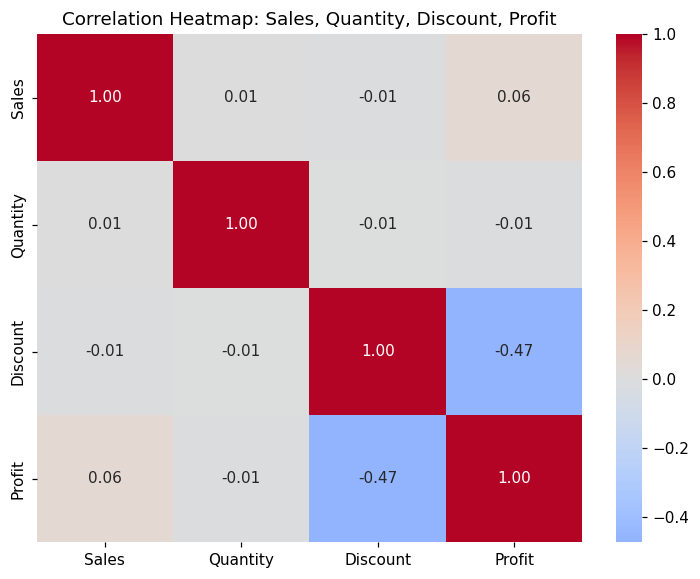

In [10]:
# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()


**Interpretation:** The strongest relationship by far is **Discount and Profit at r ≈ -0.47**
— a clear negative correlation, meaning heavier discounts tend to come with lower (or negative)
profit. No pair has a strong positive correlation; Sales and Profit are only weakly linked
(r ≈ 0.06), and Quantity barely relates to anything (all correlations near 0). This suggests
discounting is the single biggest lever tied to profit erosion in this data, while order size and
quantity aren't strongly driving it either way.

## Task 5: Time-Based Trend
**What to do:** Plot monthly total sales over time as a line chart and look for seasonal patterns.

In [11]:
# Resample data to monthly totals
# Note: pandas has deprecated the 'M' alias in favor of 'ME' (month end) in recent versions
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()


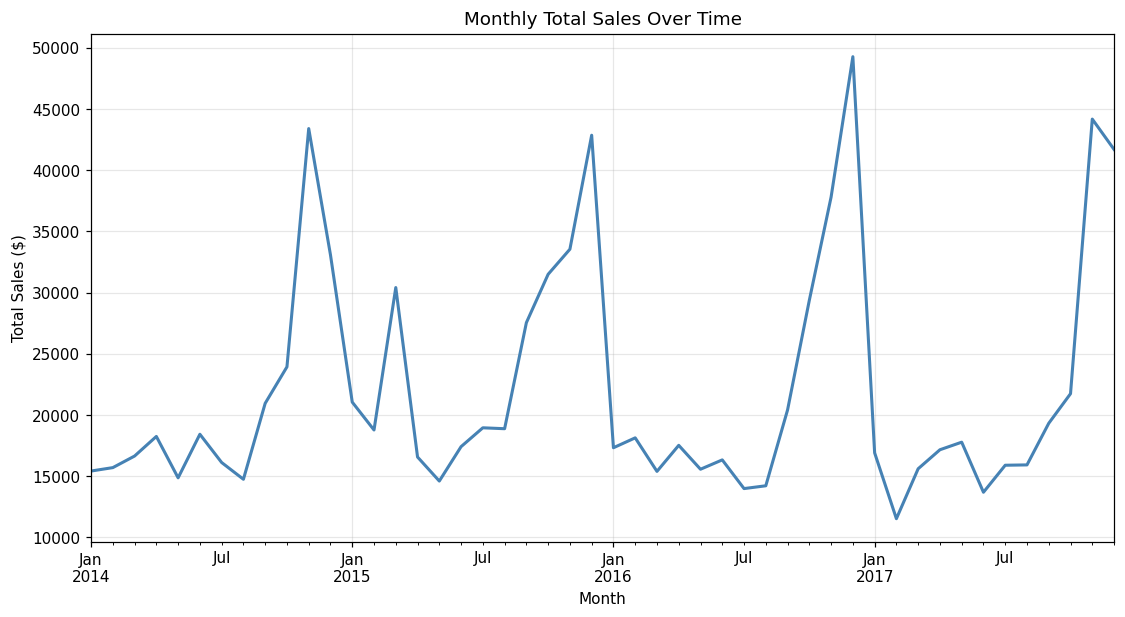

In [12]:
# Plot the monthly sales trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation:** Yes — there's a strong, repeating seasonal pattern. **November and
December average \$40.7K in sales combined per month, versus \$18.4K for the rest of the year**
— roughly 2.2x higher, consistent with end-of-year holiday shopping, and this spike repeats in
every year from 2014 to 2017. The quietest stretch is consistently **January–February** each
year (the low point is Feb 2017 at \$11.5K), right after the holiday peak fades and before
spring activity picks back up.

## Task 6: Reflection Questions

**1. The Sales histogram is likely right-skewed. Why does this happen in retail data?**
Most customers buy everyday, low-cost items, so the bulk of orders cluster at the low end of the
price range. A smaller number of customers occasionally buy expensive, high-ticket items (like a
copier or a bookcase), and those large-but-rare orders stretch the tail of the distribution far
to the right without there being enough of them to shift where most of the data sits.

**2. You found outliers in Profit. Should you remove them? What information might you lose?**
Not automatically — these outliers are legitimate business events, not data errors. The high-loss
outliers are exactly the orders that reveal where heavy discounting is destroying margin, and the
high-profit outliers show what a great order looks like; removing either would hide the very
patterns the business most needs to see and act on. It's usually better to flag and investigate
them than to delete them outright.

**3. If Discount and Profit have a negative correlation, does that mean the company should stop
giving discounts?**
No — correlation isn't causation, and discounts can still serve a purpose (clearing inventory,
winning a competitive deal, building customer loyalty) even if they compress margin on that
specific order. The right response is to look closer at *which* discount levels or categories
turn profit negative, and cap or target discounting there, rather than eliminating discounts
altogether.

**4. Looking at your monthly sales trend — if you were a store manager, what action would you
take based on this chart?**
I'd staff up, increase inventory, and lock in supplier orders well ahead of the November–December
surge so stock doesn't run out during the highest-revenue window, and I'd use the quiet
January–February period to run promotions or clear slow-moving stock rather than just letting
sales stay flat.

---
## Submission checklist
- [x] All visualizations rendered (not just code — plots visible below)
- [x] Written interpretation for each plot (2–3+ sentences)
- [x] All charts have titles, axis labels, and appropriate formatting
- [x] File name: `module_2_class_3_Khamidullokhon-Abduvokhidov.ipynb`

**Due before the next class.**